## Validation against tidal gauge data

Contains comparision of model output with tidal gauge data by calculating metrics and plotting a time series of water level.

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import metrics
from modules import read_files as read
import matplotlib.pyplot as plt
import pandas as pd

### Configuration

In [2]:
# period, skip first day
start_date = '2023-01-14'
end_date = '2023-01-18T00'

# model output
dir_model_output = '../../data/model_output'
folder_name = 'L1'
layer = 1
base_name = 'tide gauge Gomera' 

# tidal gauge data
dir_gauge = '../../data/tide_gauge/26428_55105_3463_SEA_LEVEL_20230113110137_20230223110137.csv'

### Reading files

In [3]:
# model output
all_results = read.read_files(base_dir=dir_model_output, folder=folder_name, name=base_name)
model_wl = all_results[layer]['water_level'].loc[start_date:end_date]

# tidal gauge
gauge_wl = pd.read_csv(
    dir_gauge,
    sep="\t",          # Tab-separated
    skiprows=1,        # Skip the metadata line
    na_values=-9999.9, # Convert the null value to NaN
    encoding="utf-8"
)

gauge_wl['date'] = pd.to_datetime(gauge_wl['Fecha (GMT)']) 
gauge_wl['water_level'] = gauge_wl['Nivel (cm)'] / 100
gauge_wl = gauge_wl[['date', 'water_level']]
gauge_wl.set_index('date', inplace=True)
gauge_wl = gauge_wl.loc[start_date:end_date]
gauge_wl.head()


,water_level
date,
2023-01-14 00:00:00,0.916
2023-01-14 01:00:00,1.061
2023-01-14 02:00:00,1.263
2023-01-14 03:00:00,1.473
2023-01-14 04:00:00,1.645


### Comparision

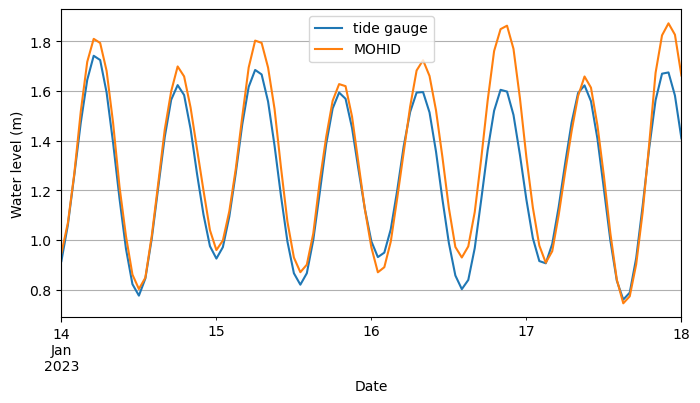

In [4]:
gauge_wl['water_level'].plot(label='tide gauge')
model_wl.plot(label='MOHID',  figsize=(8, 4))
plt.legend()
plt.ylabel('Water level (m)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [5]:
# define metrics to calculate
metric_fns = [metrics.rmse, metrics.bias, metrics.mss, metrics.pearson_r]

df_metrics = metrics.compare_multi_metrics(
    run=all_results[layer], 
    reference=gauge_wl, 
    metric_fns = metric_fns)

df_metrics

,variable,rmse,bias,mss,pearson_r
0,water_level,0.103855,0.068768,0.971374,0.974848
